In [9]:
!pip install gymnasium[box2d] torch numpy matplotlib

This block installs all required dependencies for the project.
Gymnasium with Box2D provides the LunarLander environment and its physics engine.
PyTorch will be used later for implementing neural network-based agents.
NumPy supports numerical computations, and Matplotlib is used for visualization.

In [10]:
import gymnasium as gym
import numpy as np

env=gym.make("LunarLander-v3")
obs,info=env.reset()
print("observation:",obs)
print("action space:",env.action_space)
print("observation sapce:",env.observation_space)


observation: [-0.00777721  1.4207294  -0.787766    0.43593904  0.00901865  0.17844072
  0.          0.        ]
action space: Discrete(4)
observation sapce: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


This block creates the LunarLander-v3 environment and initializes it by calling reset().
It retrieves the initial observation, which represents the starting state of the agent.
The code also prints the observation, action space, and observation space
to help understand what inputs the agent receives and what actions it can take.

In [11]:
env=gym.make("LunarLander-v3")
obs,info=env.reset()
done=False
truncated=False
tot_reward=0

for step in range(20):
  action=env.action_space.sample()
  next_obs,reward,done,truncated,info=env.step(action)
  print(f"STEP {step+1}")
  print("action:",action)
  print("reward:",reward)
  print("next_obs:",next_obs)
  print("done:",done)
  print("truncated:",truncated)
  print("-"*40)
  tot_reward+=reward
  obs=next_obs
  if done or truncated:
    break

print("total reward:",tot_reward)

STEP 1
action: 0
reward: -1.1734433022549524
next_obs: [-0.00513535  1.4042065  -0.25972003 -0.16202706  0.00589279  0.05822491
  0.          0.        ]
done: False
truncated: False
----------------------------------------
STEP 2
action: 3
reward: -0.5331887136798901
next_obs: [-0.0076354   1.3999616  -0.25122634 -0.18866105  0.00709679  0.02408225
  0.          0.        ]
done: False
truncated: False
----------------------------------------
STEP 3
action: 3
reward: -0.4376787881908786
next_obs: [-0.01005955  1.3951136  -0.24169712 -0.21546425  0.00639023 -0.01413252
  0.          0.        ]
done: False
truncated: False
----------------------------------------
STEP 4
action: 3
reward: -0.5032277790382966
next_obs: [-0.01241541  1.3896575  -0.2331393  -0.24248685  0.00396968 -0.04841544
  0.          0.        ]
done: False
truncated: False
----------------------------------------
STEP 5
action: 2
reward: -0.023288405564545644
next_obs: [-1.4864540e-02  1.3842242e+00 -2.4201953e-01 -

This block runs a short interaction loop with the environment using random actions.
At each step, an action is sampled from the action space and passed to env.step().
The environment returns the next state, reward, and termination signals (done and truncated).
The code prints these values to illustrate how the environment evolves over time
and accumulates the total reward across the steps.

In [12]:
import torch
import torch.nn as nn

env=gym.make("LunarLander-v3")
obs,info=env.reset()
obs_dim=env.observation_space.shape[0]
act_dim=env.action_space.n

class ActorCritic(nn.Module):

  def __init__(self, obs_dim, act_dim):
    super().__init__()
    self.shared=nn.Sequential(
        nn.Linear(obs_dim,256),
        nn.ReLU(),
        nn.Linear(256,256),
        nn.ReLU()
    )
    self.policy_head=nn.Linear(256,act_dim)
    self.value_head=nn.Linear(256,1)

  def forward(self,x):
    x=self.shared(x)
    logits=self.policy_head(x)
    value=self.value_head(x)
    return logits,value

model=ActorCritic(obs_dim, act_dim)
state=torch.tensor(obs, dtype=torch.float32)
logits, value=model(state)
print(logits)
print(value)

tensor([-0.0522,  0.0674, -0.0676,  0.0138], grad_fn=<ViewBackward0>)
tensor([-0.1009], grad_fn=<ViewBackward0>)


This code builds a simple Actor-Critic neural network for the LunarLander-v3 environment. It first creates the environment and gets the observation dimension and action dimension from the state and action spaces. Then it defines an ActorCritic class with shared hidden layers, a policy head that outputs action logits for decision making, and a value head that estimates the value of the current state. After creating the model, it converts the initial observation into a PyTorch tensor, passes it through the network, and prints the policy logits and state value.

In [13]:
import torch.nn.functional as F
from torch.distributions import Categorical

state=torch.tensor(obs, dtype=torch.float32)
logits, value=model(state)
probs=F.softmax(logits, dim=-1)
dis=Categorical(probs)
action=dis.sample()
next_obs, reward, done, truncated, info=env.step(action.item())
print("action:",action.item())
print("reward:",reward)
print("next_obs:",next_obs)
print("done:",done)
print("truncated:",truncated)

action: 3
reward: 1.0589042360104497
next_obs: [-0.00845346  1.4160138  -0.42202753  0.10019078  0.00792906  0.05964837
  0.          0.        ]
done: False
truncated: False


This code uses the Actor-Critic model to choose an action based on the current state. It first converts the model output logits into action probabilities, then samples an action from that probability distribution. After that, it sends the action to the environment, receives the next state and reward, and prints the result of one step of interaction between the agent and the environment.

In [14]:
states=[]
actions=[]
log_probs=[]
values=[]
rewards=[]
obs, info=env.reset()
done=False

while not done:
  state=torch.tensor(obs, dtype=torch.float32)
  logits, value=model(state)
  dis=Categorical(logits=logits)
  action=dis.sample()
  next_obs, reward, terminated, truncated, info=env.step(action.item())
  done=terminated or truncated
  states.append(state)
  actions.append(action)
  log_probs.append(dis.log_prob(action))
  values.append(value)
  rewards.append(reward)
  obs=next_obs

print("episode length:",len(rewards))
print("total rewards:",sum(rewards))

episode length: 98
total rewards: -242.0062179958922


This step runs one full episode using the Actor-Critic model and stores the trajectory data, including states, actions, log probabilities, value estimates, and rewards. These saved results will later be used to compute returns, advantages, and the training loss for updating the network.

In [15]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.0005)
num_episodes=2000
gamma=0.999
episode_reward=[]

for episode in range(num_episodes):
  obs, info=env.reset()
  log_probs=[]
  values=[]
  rewards=[]
  total_reward=0
  done=False

  while not done:
    state=torch.tensor(obs, dtype=torch.float32)
    logits, value=model(state)
    probs=F.softmax(logits, dim=-1)
    dis=Categorical(probs)
    action=dis.sample()

    next_obs, reward, terminated, truncated, info=env.step(action.item())
    done=terminated or truncated
    log_probs.append(dis.log_prob(action))
    values.append(value.squeeze())
    rewards.append(reward)
    obs=next_obs
    total_reward+=reward

  episode_reward.append(total_reward)

  returns=[]
  G=0
  for reward in reversed(rewards):
    G=reward+gamma*G
    returns.insert(0,G)

  returns=torch.tensor(returns, dtype=torch.float32)
  values=torch.stack(values)
  log_probs=torch.stack(log_probs)

  advantages=returns-values.detach()

  actor_loss=-(log_probs*advantages).mean()
  critic_loss=F.mse_loss(values,returns)
  loss=actor_loss+critic_loss

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if (episode+1)%20==0:
    avg_reward=np.mean(episode_reward[-20:])
    print(f"episode {episode+1}, average reward: {avg_reward:.2f}")

episode 20, average reward: -160.25
episode 40, average reward: -169.28
episode 60, average reward: -165.03
episode 80, average reward: -277.67
episode 100, average reward: -246.97
episode 120, average reward: -143.70
episode 140, average reward: -199.79
episode 160, average reward: -128.66
episode 180, average reward: -140.60
episode 200, average reward: -132.91
episode 220, average reward: -124.40
episode 240, average reward: -140.62
episode 260, average reward: -130.03
episode 280, average reward: -140.34
episode 300, average reward: -130.24
episode 320, average reward: -133.54
episode 340, average reward: -119.63
episode 360, average reward: -128.15
episode 380, average reward: -147.37
episode 400, average reward: -124.17
episode 420, average reward: -146.20
episode 440, average reward: -133.86
episode 460, average reward: -122.63
episode 480, average reward: -116.90
episode 500, average reward: -144.06


This block trains the Actor-Critic agent in the LunarLander environment. The agent collects rewards, action probabilities, and value estimates during each episode, then uses them to compute returns, advantages, and losses. After that, the model parameters are updated so the agent can gradually learn a better policy and value function.

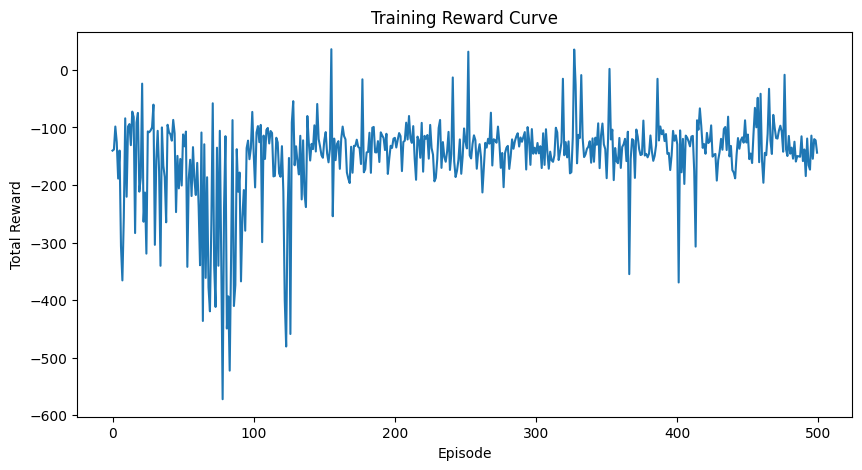

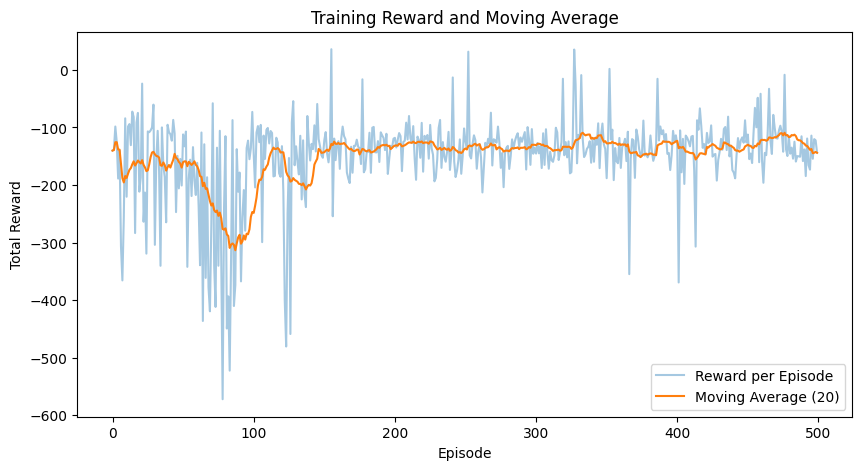

Final evaluation rewards: [np.float64(-112.15292568039217), np.float64(-98.69993984261203), np.float64(-131.27359892113014), np.float64(-120.12984442703134), np.float64(-146.8413666561112), np.float64(-100.52817566884232), np.float64(-119.00370022326587), np.float64(-110.14097699654593), np.float64(-245.244774044316), np.float64(21.841260314980616)]
Average evaluation reward: -116.21740421452664


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(episode_reward)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Reward Curve")
plt.show()

moving_avg=[]
window=20

for i in range(len(episode_reward)):
    start=max(0, i-window+1)
    avg=np.mean(episode_reward[start:i+1])
    moving_avg.append(avg)

plt.figure(figsize=(10,5))
plt.plot(episode_reward, alpha=0.4, label="Reward per Episode")
plt.plot(moving_avg, label="Moving Average (20)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training Reward and Moving Average")
plt.legend()
plt.show()

eval_rewards=[]

for _ in range(10):
    obs, info=env.reset()
    done=False
    total_reward=0

    while not done:
        state=torch.tensor(obs, dtype=torch.float32)

        with torch.no_grad():
            logits, value=model(state)
            probs=F.softmax(logits, dim=-1)
            action=torch.argmax(probs).item()

        obs, reward, terminated, truncated, info=env.step(action)
        done=terminated or truncated
        total_reward+=reward

    eval_rewards.append(total_reward)

print("Final evaluation rewards:", eval_rewards)
print("Average evaluation reward:", np.mean(eval_rewards))

First, plot the reward curve to show how the total reward changes over training episodes. Then compute and plot a moving average to make the overall learning trend easier to see. Finally, run several evaluation episodes without updating the model to measure the final performance of the trained agent.